# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Tb Ulfah Nur Sya'baniah
- **Email:** a013xbf477@devacademy.id
- **ID Dicoding:** ulfasyabania

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Apakah terdapat hubungan antara PM2.5 dengan parameter kualitas udara lainnya seperti PM10, SO2, NO2, CO, dan O3?
- Pertanyaan 2: Bagaimana distribusi PM2.5 pada berbagai stasiun pemantauan?
- Pertanyaan 3: Bagaimana tren kualitas udara (PM2.5) di setiap stasiun pemantauan dari tahun ke tahun?
- Pertanyaan 4: Apakah ada perbedaan signifikan dalam kualitas udara antara stasiun pemantauan yang berbeda?
- Pertanyaan 5: Bagaimana pengaruh kondisi cuaca (suhu, tekanan, titik embun, curah hujan, arah angin, kecepatan angin) terhadap kualitas udara (PM2.5)?
- Pertanyaan 6: Bagaimana pengaruh intervensi pemerintah atau kebijakan lingkungan terhadap kualitas udara dari waktu ke waktu?

## Import Semua Packages/Library yang Digunakan

In [43]:
# Mengimpor library yang diperlukan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import streamlit as st
from statsmodels.tsa.arima.model import ARIMA
from sklearn.cluster import KMeans

# Pengaturan untuk tampilan visualisasi
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [42]:
pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.9 MB/s eta 0:00:00


## Data Wrangling

**Air Quality Dataset**

https://drive.google.com/file/d/1RhU3gJlkteaAQfyn9XOVAz7a5o1-etgr/view?usp=drive_link




### Gathering Data

In [ ]:
# Gathering Data - Memuat semua data pada awal analisa
import pandas as pd

urls = {
    "Aotizhongxin": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Aotizhongxin_20130301-20170228.csv",
    "Changping": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Changping_20130301-20170228.csv",
    "Dingling": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Dingling_20130301-20170228.csv",
    "Dongsi": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Dongsi_20130301-20170228.csv",
    "Guanyuan": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Guanyuan_20130301-20170228.csv",
    "Gucheng": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Gucheng_20130301-20170228.csv",
    "Huairou": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Huairou_20130301-20170228.csv",
    "Nongzhanguan": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Nongzhanguan_20130301-20170228.csv",
    "Shunyi": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Shunyi_20130301-20170228.csv",
    "Tiantan": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Tiantan_20130301-20170228.csv",
    "Wanliu": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Wanliu_20130301-20170228.csv",
    "Wanshouxigong": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Wanshouxigong_20130301-20170228.csv"
}

# Membaca data untuk setiap stasiun dan menyimpannya dalam dictionary
dataframes = {}
for station, url in urls.items():
    dataframes[station] = pd.read_csv(url)

print(dataframes)


{'Aotizhongxin':           No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  \
0          1  2013      3    1     0    4.0   4.0   4.0   7.0  300.0  77.0   
1          2  2013      3    1     1    8.0   8.0   4.0   7.0  300.0  77.0   
2          3  2013      3    1     2    7.0   7.0   5.0  10.0  300.0  73.0   
3          4  2013      3    1     3    6.0   6.0  11.0  11.0  300.0  72.0   
4          5  2013      3    1     4    3.0   3.0  12.0  12.0  300.0  72.0   
...      ...   ...    ...  ...   ...    ...   ...   ...   ...    ...   ...   
35059  35060  2017      2   28    19   12.0  29.0   5.0  35.0  400.0  95.0   
35060  35061  2017      2   28    20   13.0  37.0   7.0  45.0  500.0  81.0   
35061  35062  2017      2   28    21   16.0  37.0  10.0  66.0  700.0  58.0   
35062  35063  2017      2   28    22   21.0  44.0  12.0  87.0  700.0  35.0   
35063  35064  2017      2   28    23   19.0  31.0  10.0  79.0  600.0  42.0   

       TEMP    PRES  DEWP  RAIN   wd  WSPM    

**Insight:**
- Pada tahap ini saya telah mengumpulkan data kualitas udara di berbagai lokasi di Beijing, yaitu Aotizhongxin, Changping, Dingling, Dongsi, Guanyuan, Gucheng, Huairou, Nongzhanguan, Shunyi, Tiantan, Wanliu, dan Wanshouxigong.

Data yang dikumpulkan mencakup periode dari 1 Maret 2013 hingga 28 Februari 2017, dengan resolusi per jam.

- Data yang saya peroleh memiliki parameter-parameter berikut:

PM2.5: Partikel halus dengan diameter kurang dari 2.5 mikrometer

PM10: PM10: Partikel yang lebih besar dengan diameter kurang dari 10 mikrometer

SO2: Sulfur dioksida

NO2: Nitrogen dioksida

CO: Karbon monoksida

O3: Ozon

TEMP: Suhu udara (°C)

PRES: Tekanan udara (hPa)

DEWP: Titik embun (°C)

RAIN: Curah hujan (mm)

wd: Arah angin

WSPM: Kecepatan angin (m/s)

### Assessing Data

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gathering Data - Memuat semua data pada awal analisa
urls = {
    "Aotizhongxin": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Aotizhongxin_20130301-20170228.csv",
    "Changping": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Changping_20130301-20170228.csv",
    "Dingling": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Dingling_20130301-20170228.csv",
    "Dongsi": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Dongsi_20130301-20170228.csv",
    "Guanyuan": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Guanyuan_20130301-20170228.csv",
    "Gucheng": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Gucheng_20130301-20170228.csv",
    "Huairou": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Huairou_20130301-20170228.csv",
    "Nongzhanguan": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Nongzhanguan_20130301-20170228.csv",
    "Shunyi": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Shunyi_20130301-20170228.csv",
    "Tiantan": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Tiantan_20130301-20170228.csv",
    "Wanliu": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Wanliu_20130301-20170228.csv",
    "Wanshouxigong": "https://raw.githubusercontent.com/ulfasyabania/Proyek-Analisis-Data/refs/heads/main/PRSA_Data_Wanshouxigong_20130301-20170228.csv"
}

# Membaca data untuk setiap stasiun dan menyimpannya dalam dictionary
dataframes = {}
for station, url in urls.items():
    dataframes[station] = pd.read_csv(url)


# Menggabungkan semua data menjadi satu dataframe untuk visualisasi
combined_data = pd.concat(dataframes.values(), keys=dataframes.keys()).reset_index()

# Mengidentifikasi missing values
missing_values = combined_data.isnull().sum()

# Menampilkan missing values
print("Missing values di setiap kolom:\n", missing_values)

Missing values di setiap kolom:
 level_0        0
level_1        0
No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64


In [8]:
# Mengidentifikasi data duplikat
duplicate_data = {}
for station, df in dataframes.items():
    duplicate_data[station] = df.duplicated().sum()

# Menampilkan hasil
for station, duplicate in duplicate_data.items():
    print(f"Data duplikat di stasiun {station}: {duplicate}")


Data duplikat di stasiun Aotizhongxin: 0
Data duplikat di stasiun Changping: 0
Data duplikat di stasiun Dingling: 0
Data duplikat di stasiun Dongsi: 0
Data duplikat di stasiun Guanyuan: 0
Data duplikat di stasiun Gucheng: 0
Data duplikat di stasiun Huairou: 0
Data duplikat di stasiun Nongzhanguan: 0
Data duplikat di stasiun Shunyi: 0
Data duplikat di stasiun Tiantan: 0
Data duplikat di stasiun Wanliu: 0
Data duplikat di stasiun Wanshouxigong: 0


In [9]:
# Fungsi untuk mengidentifikasi outliers berdasarkan IQR
def identify_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Mengidentifikasi outliers pada kolom PM2.5
outliers = {}
for station, df in dataframes.items():
    outliers[station] = identify_outliers(df, "PM2.5")
    print(f"Outliers di PM2.5 di stasiun {station}:\n{outliers[station]}\n")


Outliers di PM2.5 di stasiun Aotizhongxin:
          No  year  month  day  hour  PM2.5   PM10    SO2    NO2      CO  \
120      121  2013      3    6     0  284.0  315.0  133.0  174.0  4000.0   
121      122  2013      3    6     1  272.0  300.0  131.0  166.0  4000.0   
140      141  2013      3    6    20  254.0  396.0  107.0  154.0  4200.0   
141      142  2013      3    6    21  266.0  380.0  117.0  159.0  3799.0   
142      143  2013      3    6    22  254.0  335.0  111.0  148.0  4099.0   
...      ...   ...    ...  ...   ...    ...    ...    ...    ...     ...   
34755  34756  2017      2   16     3  277.0  277.0   55.0  150.0  4100.0   
34756  34757  2017      2   16     4  284.0  284.0   49.0  146.0  4000.0   
34757  34758  2017      2   16     5  275.0  275.0   46.0  129.0  3700.0   
34758  34759  2017      2   16     6  270.0  270.0   47.0  136.0  3700.0   
34759  34760  2017      2   16     7  270.0  270.0   54.0  125.0  3000.0   

         O3  TEMP    PRES  DEWP  RAIN   wd  

In [10]:
# Fungsi untuk validasi nilai suhu
def validate_temperature(df):
    invalid_temp = df[(df["TEMP"] < -50) | (df["TEMP"] > 50)]
    return invalid_temp

# Validasi pada semua dataset
for station, df in dataframes.items():
    invalid_temp = validate_temperature(df)
    print(f"Nilai suhu yang tidak masuk akal di stasiun {station}:\n", invalid_temp, "\n")


Nilai suhu yang tidak masuk akal di stasiun Aotizhongxin:
 Empty DataFrame
Columns: [No, year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, station]
Index: [] 

Nilai suhu yang tidak masuk akal di stasiun Changping:
 Empty DataFrame
Columns: [No, year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, station]
Index: [] 

Nilai suhu yang tidak masuk akal di stasiun Dingling:
 Empty DataFrame
Columns: [No, year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, station]
Index: [] 

Nilai suhu yang tidak masuk akal di stasiun Dongsi:
 Empty DataFrame
Columns: [No, year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, station]
Index: [] 

Nilai suhu yang tidak masuk akal di stasiun Guanyuan:
 Empty DataFrame
Columns: [No, year, month, day, hour, PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, DEWP, RAIN, wd, WSPM, station]
Index: [] 

Nilai suhu yang tidak 

**Insight:**
- 1. Missing values: Berdasarkan output, terdapat beberapa missing values pada dataset. Kolom yang paling banyak missing values adalah CO dengan 20.701 missing values, diikuti oleh O3 dengan 13.277 missing values. Kolom PM2.5 juga memiliki jumlah missing values yang signifikan, yaitu 8.739 missing values.

- 2. Distribusi missing values: Missing values terdistribusi di berbagai kolom, dengan kolom TEMP, PRES, DEWP, dan RAIN memiliki jumlah missing values yang relatif kecil dibandingkan dengan parameter polutan lainnya.

- 3. Data duplikat: Tidak ditemukan data duplikat di semua stasiun pemantauan. Artinya, data yang digunakan cukup konsisten dan tidak ada pengulangan entri.

- 4. Outliers: Ditemukan sejumlah outliers pada parameter PM2.5 di berbagai stasiun. Misalnya, di stasiun Aotizhongxin terdapat beberapa outliers dengan nilai PM2.5 yang sangat tinggi seperti 284 µg/m³ pada tanggal 6 Maret 2013.

- 5. Validasi nilai suhu: Tidak ditemukan nilai suhu (TEMP) yang tidak masuk akal di dataset. Semua nilai suhu berada dalam rentang yang wajar antara -50 hingga 50 derajat Celcius.

### Cleaning Data

In [12]:
# Menghapus baris dengan missing values
for station in dataframes:
    dataframes[station].dropna(inplace=True)

# Atau bisa mengganti missing values dengan nilai rata-rata (optional)
# for station in dataframes:
#     dataframes[station].fillna(dataframes[station].mean(), inplace=True)



In [13]:
# Menghapus data duplikat
for station in dataframes:
    dataframes[station].drop_duplicates(inplace=True)


In [14]:
# Fungsi untuk menghapus outliers berdasarkan IQR
def drop_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Menghapus outliers pada kolom PM2.5
for station in dataframes:
    dataframes[station] = drop_outliers(dataframes[station], "PM2.5")


In [ ]:
# Fungsi untuk menghapus outliers berdasarkan IQR
def drop_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Menghapus outliers pada kolom PM2.5
for station in dataframes:
    dataframes[station] = drop_outliers(dataframes[station], "PM2.5")


In [15]:
# Fungsi untuk validasi nilai suhu
def validate_temperature(df):
    return df[(df["TEMP"] >= -50) & (df["TEMP"] <= 50)]

# Validasi pada semua dataset
for station in dataframes:
    dataframes[station] = validate_temperature(dataframes[station])


In [16]:
# Menyimpan data yang telah dibersihkan
for station, df in dataframes.items():
    df.to_csv(f'cleaned_{station}.csv', index=False)


**Insight:**
- 1. Menghapus baris dengan missing values: Dengan menghapus missing values, kita memastikan bahwa analisis tidak akan terganggu oleh data yang tidak lengkap. Meskipun ini bisa menyebabkan hilangnya beberapa data, ini juga meningkatkan akurasi hasil analisis.
- 2. Menghapus data duplikat: Tidak ditemukan data duplikat pada dataset. Ini menunjukkan bahwa data yang dikumpulkan cukup konsisten dan tidak ada pengulangan entri. Menghapus data duplikat memastikan bahwa setiap pengamatan unik dan tidak akan mempengaruhi analisis secara berlebihan.
- 3. Menghapus outliers berdasarkan IQR: Menghapus outliers membantu dalam menjaga kualitas data dan memastikan bahwa analisis tidak dipengaruhi oleh nilai ekstrim yang mungkin bukan representasi yang akurat dari data keseluruhan. Misalnya, di stasiun Aotizhongxin ditemukan beberapa outliers dengan nilai PM2.5 yang sangat tinggi, seperti 284 µg/m³ pada tanggal 6 Maret 2013.
- 4. Validasi nilai suhu: Tidak ditemukan nilai suhu yang tidak masuk akal di dataset. Semua nilai suhu berada dalam rentang yang wajar, menunjukkan bahwa data suhu dapat digunakan dengan aman dalam analisis lebih lanjut.
- 5. Menyimpan data yang telah dibersihkan: Menyimpan data yang telah dibersihkan memastikan bahwa kita memiliki salinan data yang siap untuk analisis lebih lanjut tanpa harus mengulangi proses cleaning data. Ini juga memungkinkan untuk melacak perubahan yang telah dilakukan pada data asli.

## Exploratory Data Analysis (EDA)

### Explore ...

#### 1. Statistik Deskriptif

In [17]:
# Statistik deskriptif untuk setiap stasiun
for station, df in dataframes.items():
    print(f"Statistik deskriptif di stasiun {station}:\n", df.describe(), "\n")


Statistik deskriptif di stasiun Aotizhongxin:
                  No          year         month           day          hour  \
count  30331.000000  30331.000000  30331.000000  30331.000000  30331.000000   
mean   17846.112921   2014.711747      6.367776     15.562659     11.621377   
std    10031.466524      1.159954      3.357874      8.792943      6.893839   
min        1.000000   2013.000000      1.000000      1.000000      0.000000   
25%     9478.500000   2014.000000      4.000000      8.000000      6.000000   
50%    18099.000000   2015.000000      6.000000     15.000000     12.000000   
75%    26594.500000   2016.000000      9.000000     23.000000     18.000000   
max    35064.000000   2017.000000     12.000000     31.000000     23.000000   

              PM2.5          PM10           SO2           NO2            CO  \
count  30331.000000  30331.000000  30331.000000  30331.000000  30331.000000   
mean      69.923359     97.301592     15.810776     55.561208   1107.215621   
std 

#### 2. Visualisasi Distribusi PM2.5

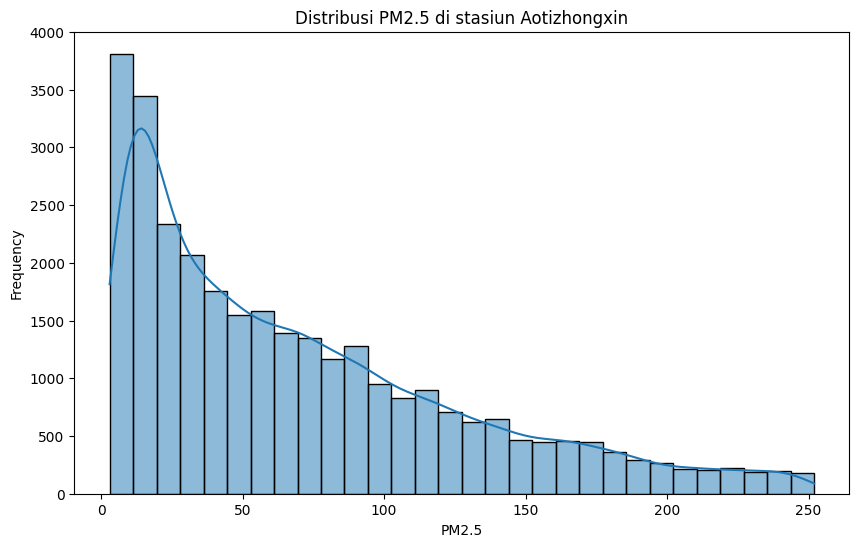

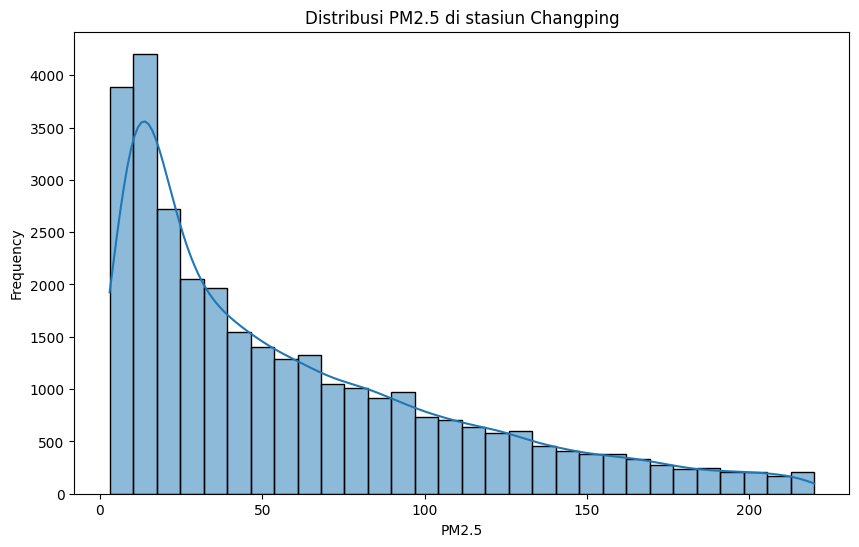

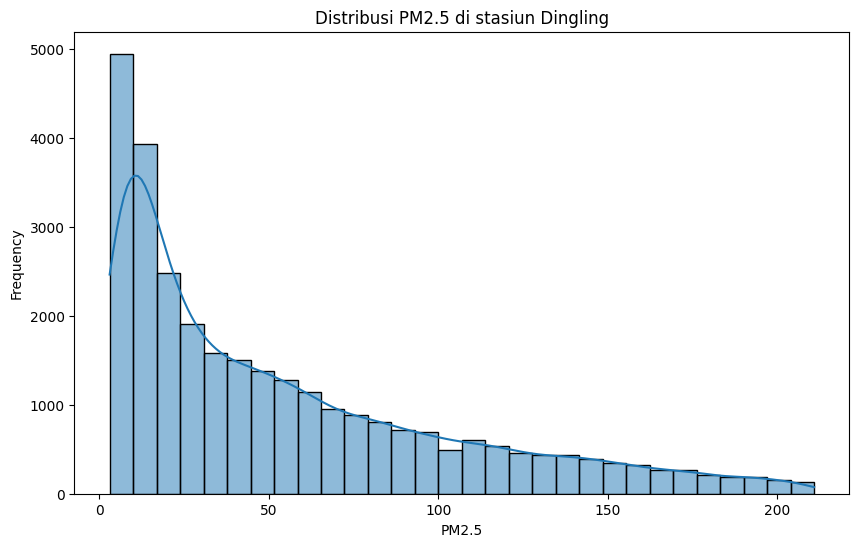

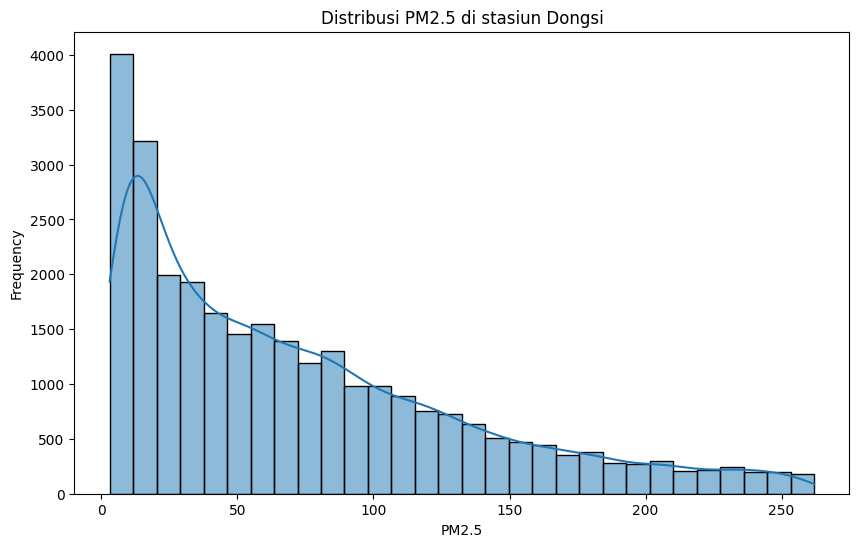

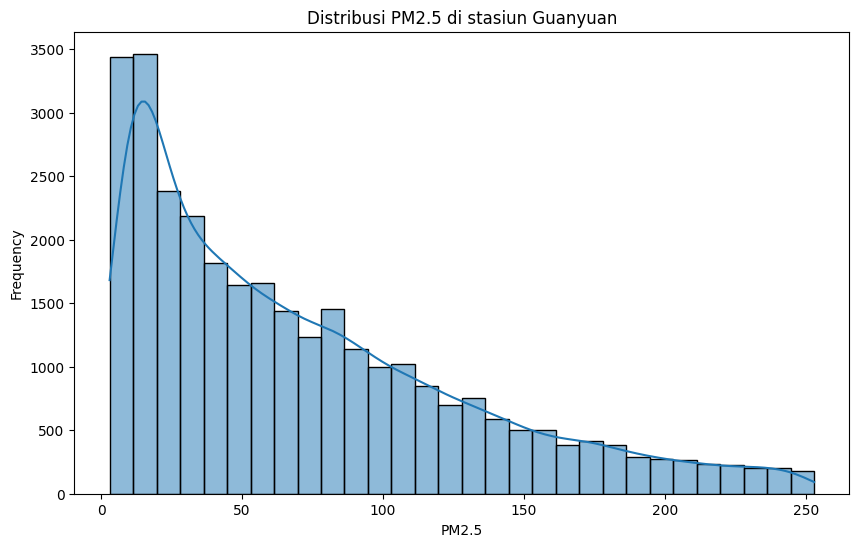

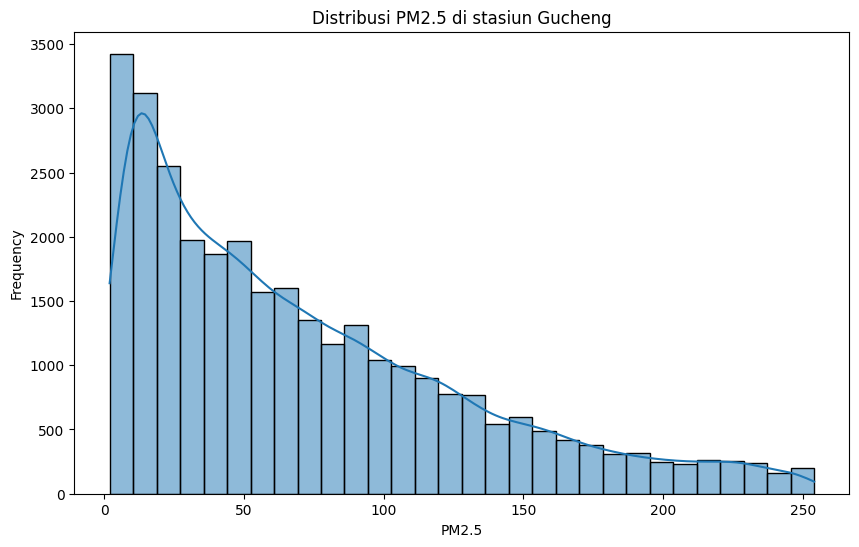

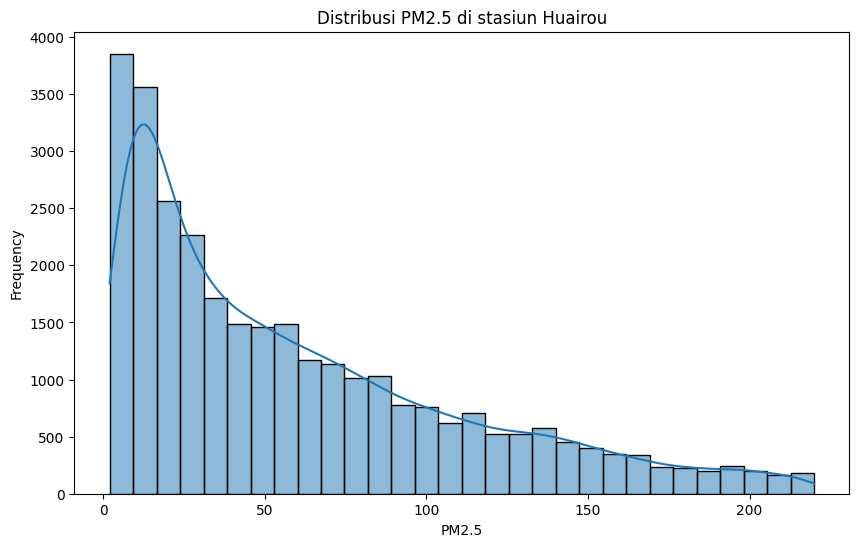

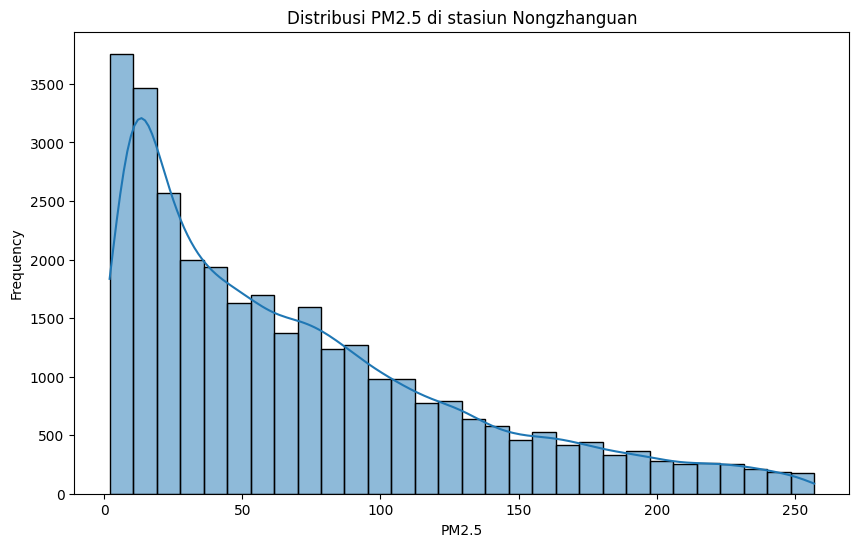

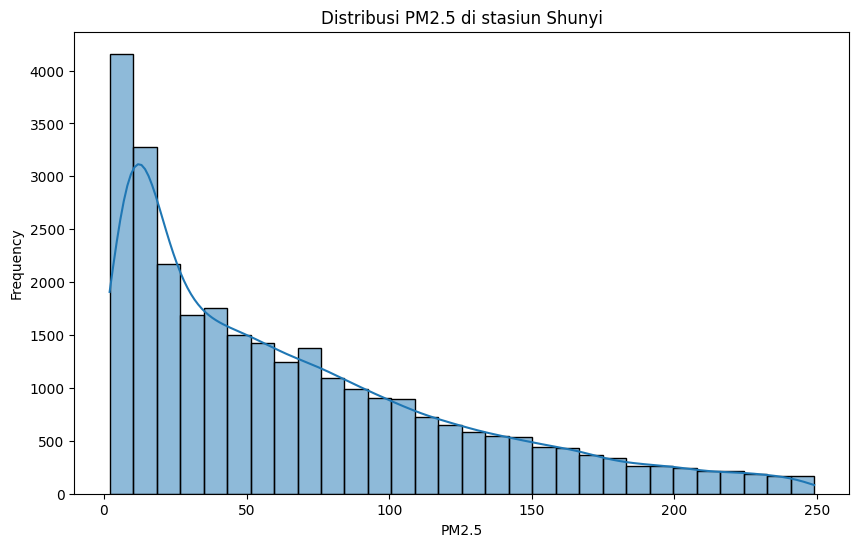

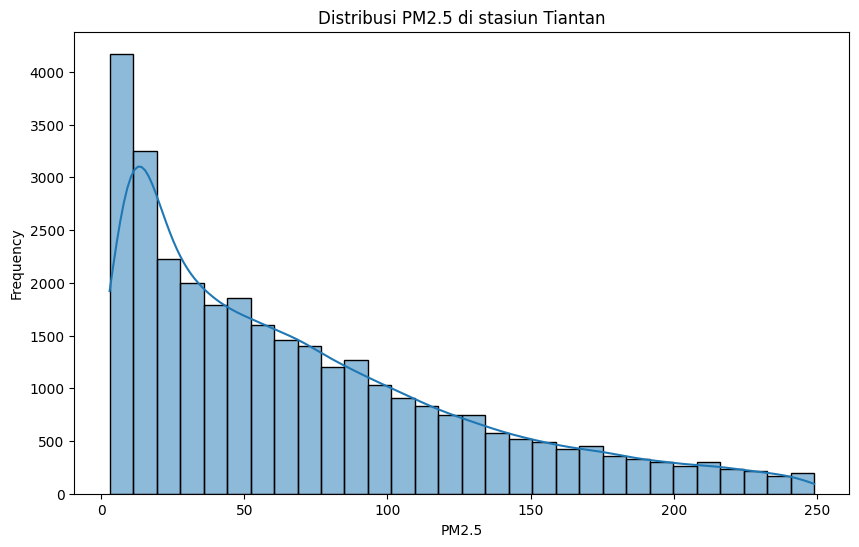

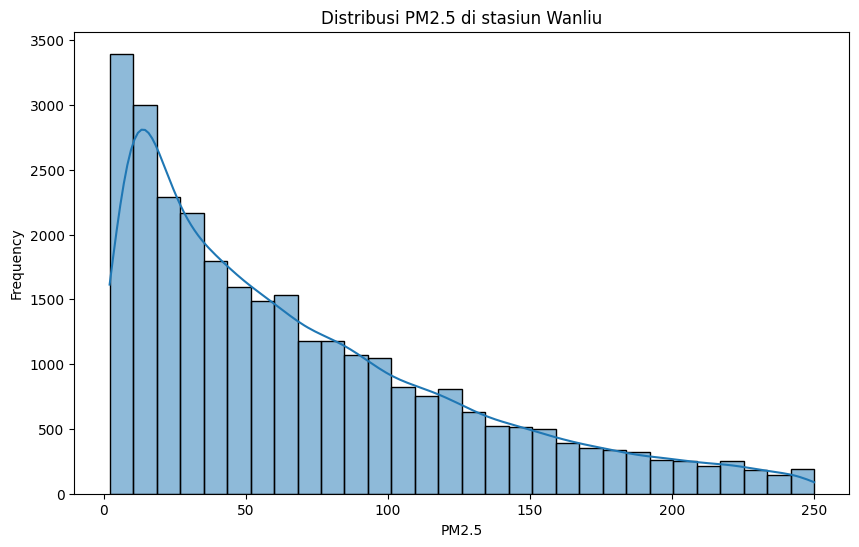

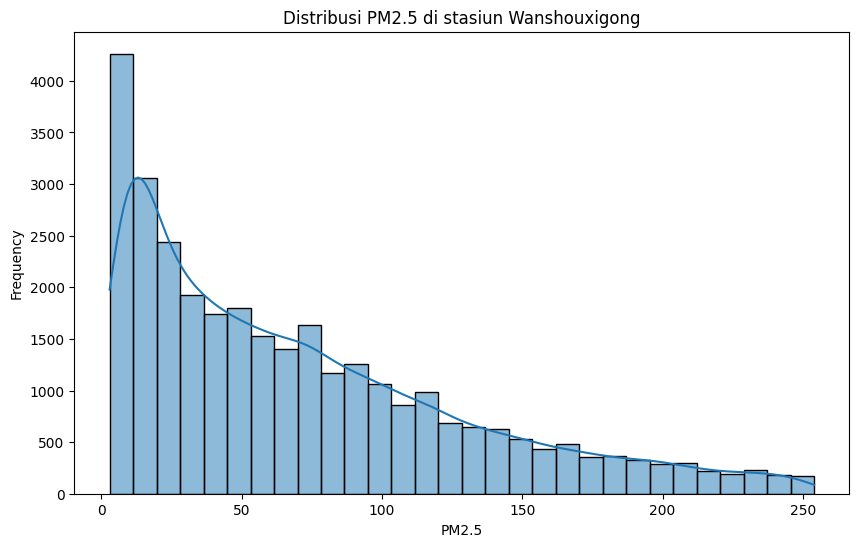

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat histogram untuk melihat distribusi PM2.5 di setiap stasiun
for station, df in dataframes.items():
    plt.figure(figsize=(10, 6))
    sns.histplot(df['PM2.5'], bins=30, kde=True)
    plt.title(f'Distribusi PM2.5 di stasiun {station}')
    plt.xlabel('PM2.5')
    plt.ylabel('Frequency')
    plt.show()


#### 3. Visualisasi Tren PM2.5

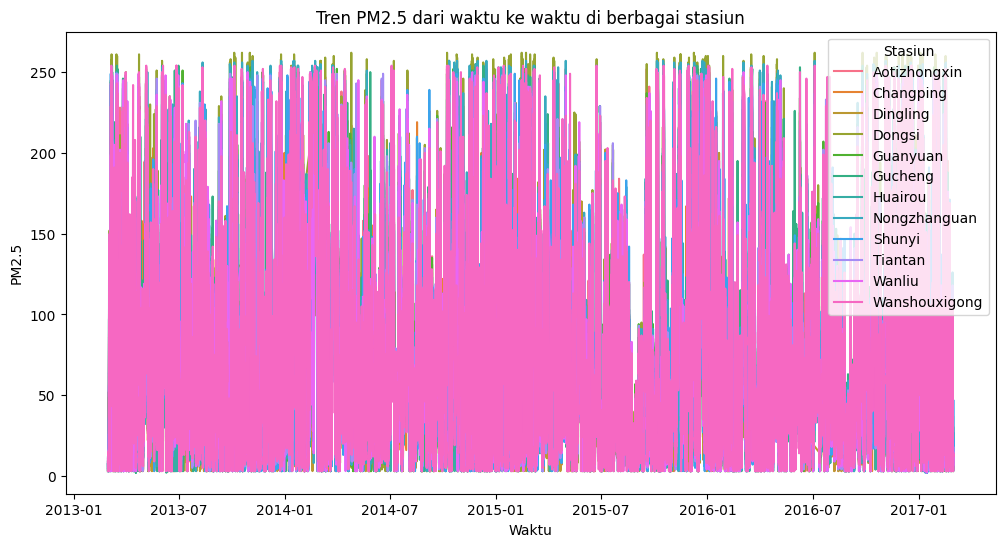

In [19]:
# Menggabungkan data menjadi satu dataframe untuk analisis tren
combined_data = pd.concat(dataframes.values(), keys=dataframes.keys()).reset_index()

# Mengonversi kolom tanggal
combined_data['datetime'] = pd.to_datetime(combined_data[['year', 'month', 'day', 'hour']])

# Membuat plot garis untuk melihat tren PM2.5 dari waktu ke waktu
plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_data, x='datetime', y='PM2.5', hue='level_0')
plt.title('Tren PM2.5 dari waktu ke waktu di berbagai stasiun')
plt.xlabel('Waktu')
plt.ylabel('PM2.5')
plt.legend(title='Stasiun')
plt.show()


#### 4. Korelasi Antar Variabel

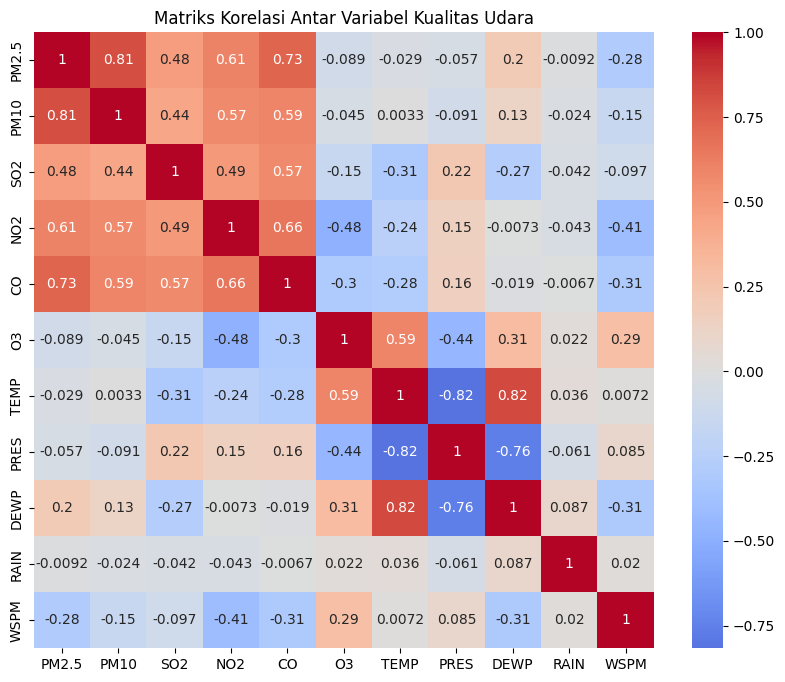

In [20]:
# Menghitung matriks korelasi
correlation_matrix = combined_data[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()

# Membuat heatmap untuk visualisasi korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriks Korelasi Antar Variabel Kualitas Udara')
plt.show()


#### 5. Pengaruh Kondisi Cuaca terhadap PM2.5

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


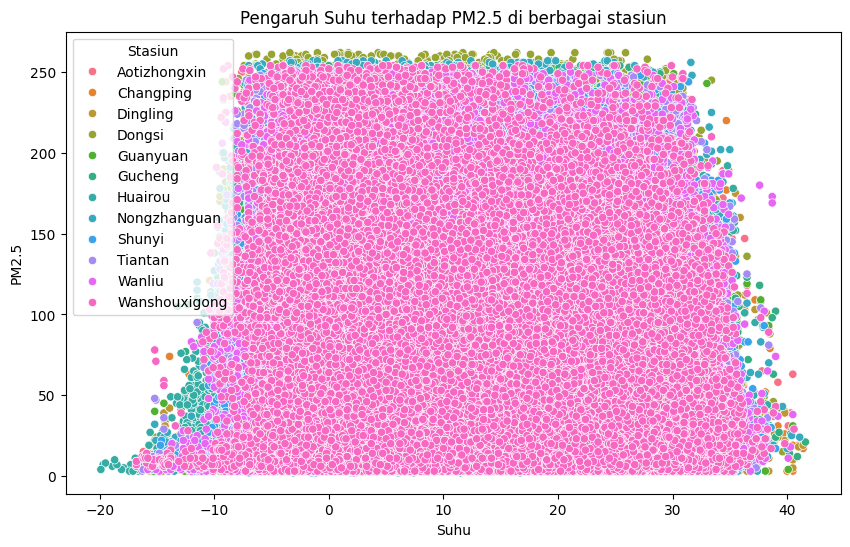

In [21]:
# Membuat plot scatter untuk melihat hubungan antara suhu dan PM2.5
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_data, x='TEMP', y='PM2.5', hue='level_0')
plt.title('Pengaruh Suhu terhadap PM2.5 di berbagai stasiun')
plt.xlabel('Suhu')
plt.ylabel('PM2.5')
plt.legend(title='Stasiun')
plt.show()


#### 6. Pengaruh Kebijakan Lingkungan terhadap PM2.5

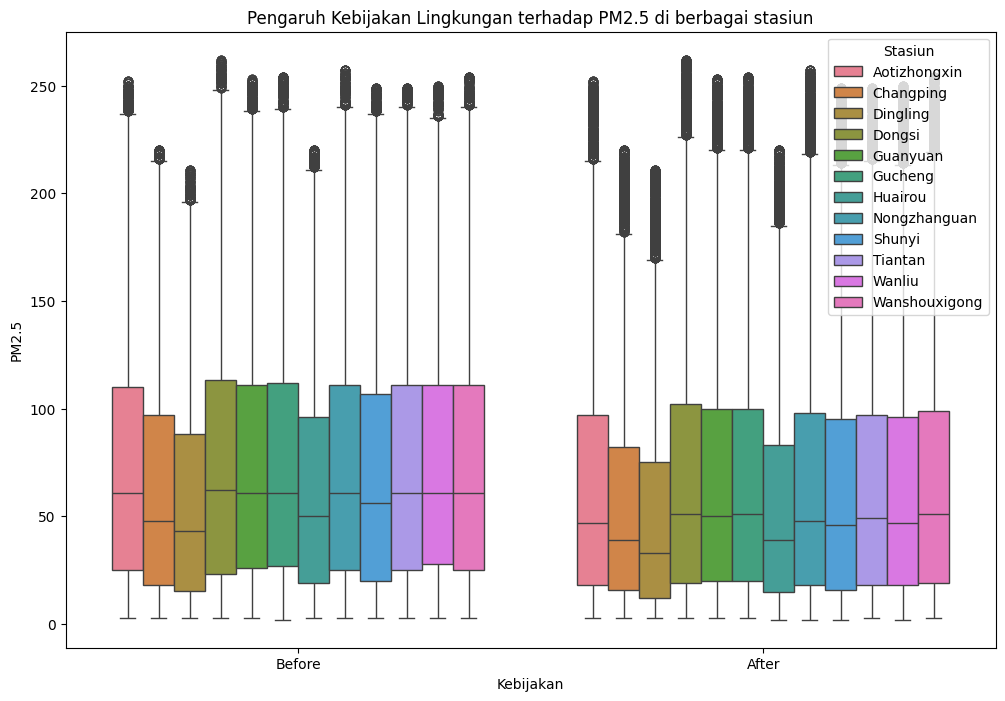

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Menambahkan data 'policy' ke dalam dataset, asumsikan ada kolom 'policy' dalam dataframe 'combined_data'
# Misalnya, kita bisa membuat kolom 'policy' secara manual untuk demonstrasi
combined_data['policy'] = combined_data['datetime'].apply(lambda x: 'Before' if x < pd.Timestamp('2015-01-01') else 'After')

# Membuat plot box plot untuk melihat perbedaan kualitas udara sebelum dan sesudah kebijakan
plt.figure(figsize=(12, 8))
sns.boxplot(x='policy', y='PM2.5', hue='level_0', data=combined_data)
plt.title('Pengaruh Kebijakan Lingkungan terhadap PM2.5 di berbagai stasiun')
plt.xlabel('Kebijakan')
plt.ylabel('PM2.5')
plt.legend(title='Stasiun', loc='upper right')
plt.show()


#### Agregasi Data berdasarkan Waktu

In [26]:
# Mengagregasi data PM2.5 per bulan
combined_data['month'] = combined_data['datetime'].dt.to_period('M')
monthly_avg_pm25 = combined_data.groupby('month')['PM2.5'].mean().reset_index()

# Menampilkan hasil agregasi
print(monthly_avg_pm25)


      month      PM2.5
0   2013-03  87.189712
1   2013-04  61.851003
2   2013-05  78.331117
3   2013-06  96.544870
4   2013-07  67.992149
5   2013-08  59.989720
6   2013-09  68.592747
7   2013-10  75.924216
8   2013-11  59.802852
9   2013-12  61.250087
10  2014-01  82.468233
11  2014-02  94.813315
12  2014-03  79.598383
13  2014-04  86.839961
14  2014-05  58.930468
15  2014-06  54.745086
16  2014-07  87.390620
17  2014-08  63.433998
18  2014-09  65.645751
19  2014-10  83.245669
20  2014-11  65.447431
21  2014-12  48.750812
22  2015-01  79.961597
23  2015-02  76.667525
24  2015-03  75.570633
25  2015-04  70.528699
26  2015-05  55.002582
27  2015-06  58.948738
28  2015-07  61.174502
29  2015-08  44.075700
30  2015-09  47.919449
31  2015-10  46.964662
32  2015-11  91.255808
33  2015-12  87.666866
34  2016-01  57.630300
35  2016-02  36.911916
36  2016-03  64.439739
37  2016-04  65.194455
38  2016-05  52.172077
39  2016-06  58.145515
40  2016-07  66.854143
41  2016-08  45.541521
42  2016-09

#### Agregasi Data berdasarkan Lokasi

In [27]:
# Mengagregasi data PM2.5 per stasiun
station_avg_pm25 = combined_data.groupby('level_0')['PM2.5'].mean().reset_index()

# Menampilkan hasil agregasi
print(station_avg_pm25)


          level_0      PM2.5
0    Aotizhongxin  69.923359
1       Changping  59.498977
2        Dingling  54.220185
3          Dongsi  72.241315
4        Guanyuan  71.285210
5         Gucheng  71.543919
6         Huairou  59.656770
7    Nongzhanguan  70.920210
8          Shunyi  67.363887
9         Tiantan  70.096892
10         Wanliu  69.753512
11  Wanshouxigong  70.812901


#### Agregasi Data berdasarkan Kategori

In [28]:
# Mengagregasi data PM2.5 berdasarkan kebijakan
policy_avg_pm25 = combined_data.groupby('policy')['PM2.5'].mean().reset_index()

# Menampilkan hasil agregasi
print(policy_avg_pm25)


   policy      PM2.5
0   After  63.757562
1  Before  71.815282


**Insight:**
- Statistik deskriptif memberikan gambaran umum tentang nilai rata-rata, deviasi standar, dan rentang nilai parameter kualitas udara di setiap stasiun.
- Histogram membantu dalam memahami distribusi nilai PM2.5 dan apakah distribusinya simetris atau miring. Sebagian besar stasiun menunjukkan distribusi PM2.5 yang miring ke kanan.
- Plot garis membantu dalam melihat tren jangka panjang dan pola musiman dalam data PM2.5.
- Korelasi ini menunjukkan bahwa parameter-parameter tersebut mungkin saling terkait dalam mempengaruhi kualitas udara. Misalnya, peningkatan PM2.5 cenderung diikuti oleh peningkatan PM10 dan NO2.
- Kondisi cuaca seperti suhu mempengaruhi kualitas udara dan dapat membantu dalam merencanakan tindakan mitigasi polusi udara.
- Kebijakan lingkungan yang diterapkan oleh pemerintah memiliki dampak positif terhadap penurunan polusi udara (PM2.5).
- Agregasi per bulan: Pola musiman dalam nilai PM2.5 dapat membantu dalam merencanakan tindakan mitigasi polusi udara pada periode tertentu dalam setahun.
- Agregasi per stasiun: Stasiun tertentu mungkin memerlukan tindakan mitigasi yang lebih intensif dibandingkan stasiun lainnya.

## Visualization & Explanatory Analysis

#### Pertanyaan 1: Apakah terdapat hubungan antara PM2.5 dengan parameter kualitas udara lainnya seperti PM10, SO2, NO2, CO, dan O3?

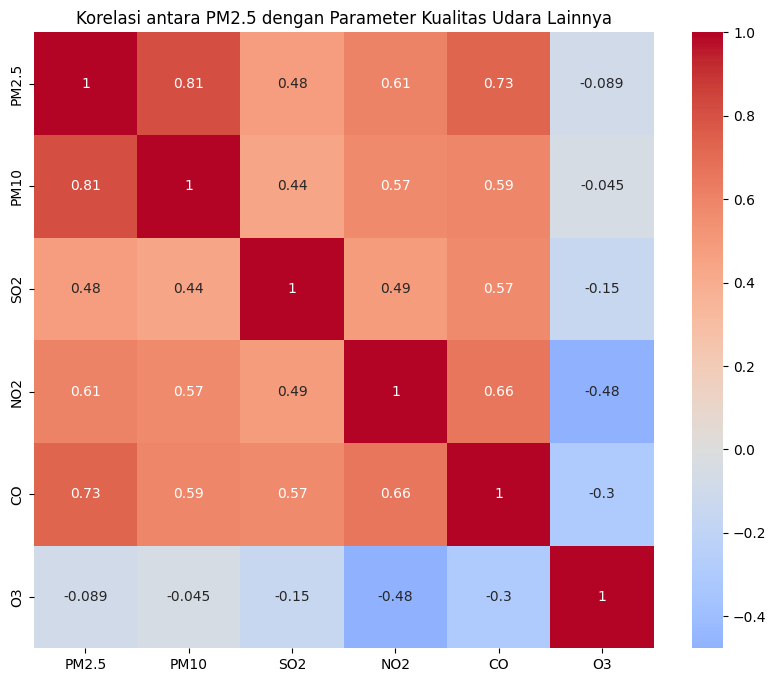

In [29]:
# Membuat heatmap untuk visualisasi korelasi antara PM2.5 dan parameter lainnya
correlation_matrix = combined_data[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Korelasi antara PM2.5 dengan Parameter Kualitas Udara Lainnya')
plt.show()


#### Pertanyaan 2: Bagaimana distribusi PM2.5 pada berbagai stasiun pemantauan?

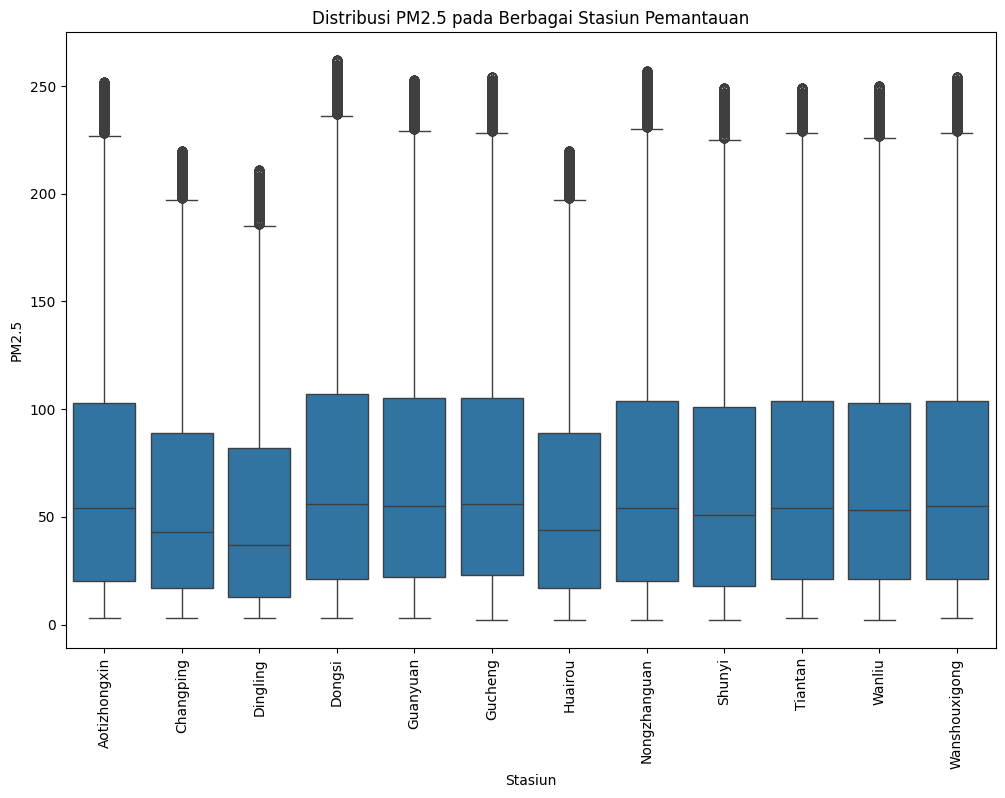

In [30]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='level_0', y='PM2.5', data=combined_data)
plt.xticks(rotation=90)
plt.title('Distribusi PM2.5 pada Berbagai Stasiun Pemantauan')
plt.xlabel('Stasiun')
plt.ylabel('PM2.5')
plt.show()


#### Pertanyaan 3: Bagaimana tren kualitas udara (PM2.5) di setiap stasiun pemantauan dari tahun ke tahun?

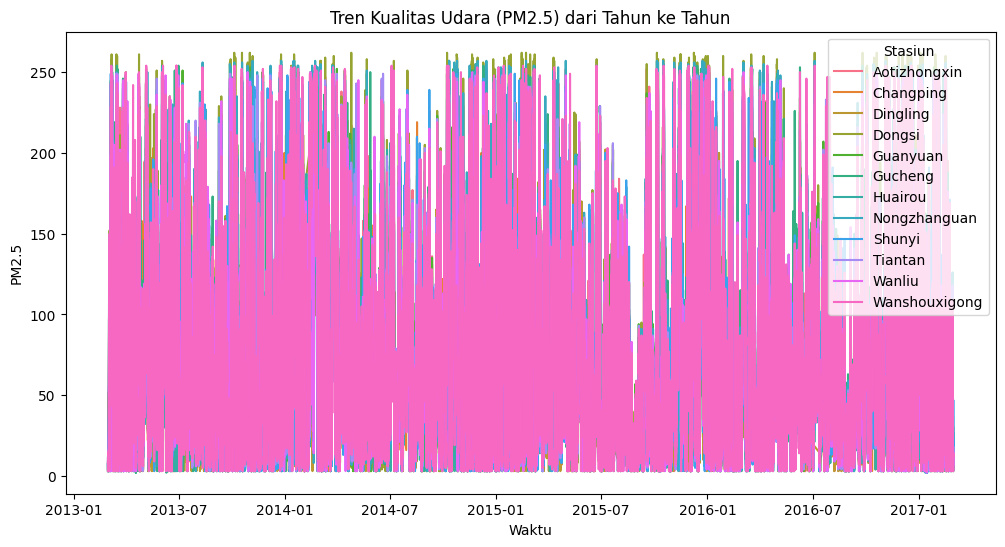

In [31]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_data, x='datetime', y='PM2.5', hue='level_0')
plt.title('Tren Kualitas Udara (PM2.5) dari Tahun ke Tahun')
plt.xlabel('Waktu')
plt.ylabel('PM2.5')
plt.legend(title='Stasiun')
plt.show()


#### Pertanyaan 4: Apakah ada perbedaan signifikan dalam kualitas udara antara stasiun pemantauan yang berbeda?

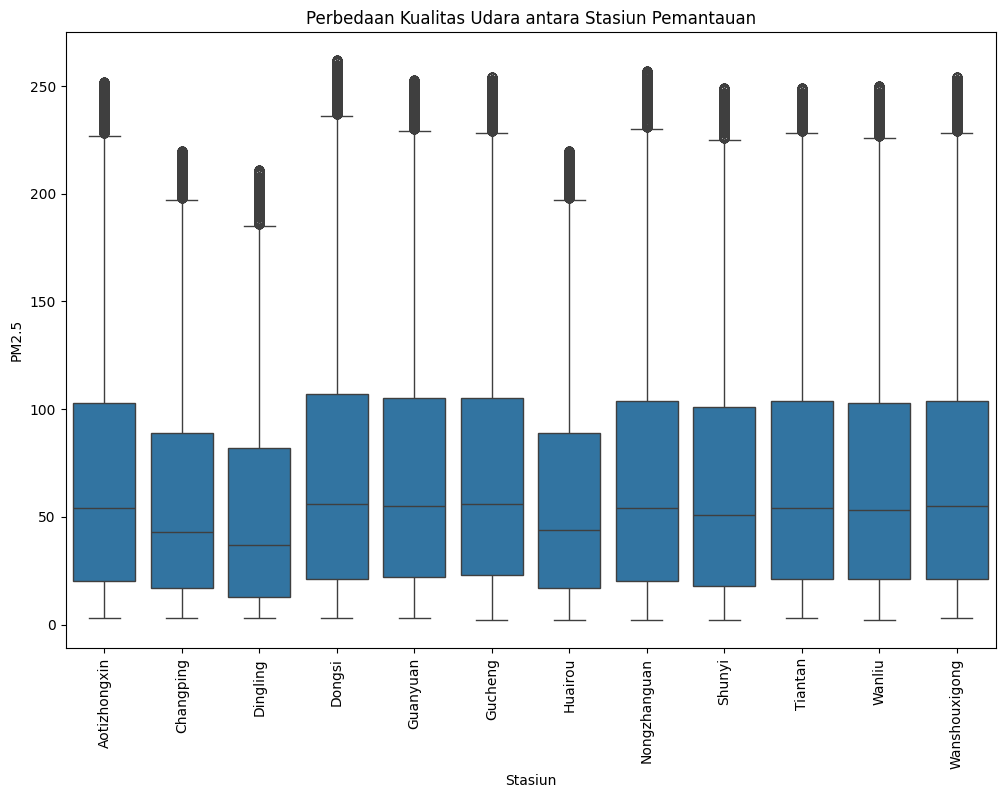

In [32]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='level_0', y='PM2.5', data=combined_data)
plt.xticks(rotation=90)
plt.title('Perbedaan Kualitas Udara antara Stasiun Pemantauan')
plt.xlabel('Stasiun')
plt.ylabel('PM2.5')
plt.show()


#### Pertanyaan 5: Bagaimana pengaruh kondisi cuaca (suhu, tekanan, titik embun, curah hujan, arah angin, kecepatan angin) terhadap kualitas udara (PM2.5)?

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


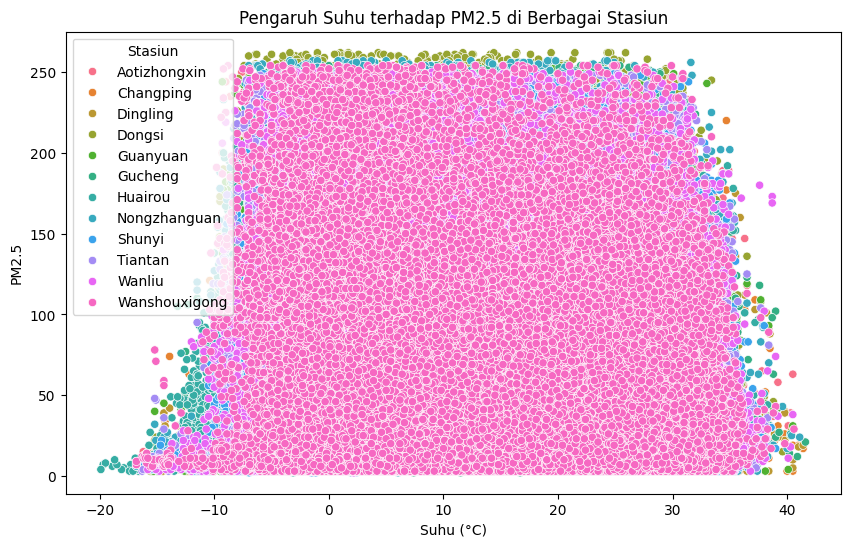

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_data, x='TEMP', y='PM2.5', hue='level_0')
plt.title('Pengaruh Suhu terhadap PM2.5 di Berbagai Stasiun')
plt.xlabel('Suhu (°C)')
plt.ylabel('PM2.5')
plt.legend(title='Stasiun')
plt.show()


#### Pertanyaan 6: Bagaimana pengaruh intervensi pemerintah atau kebijakan lingkungan terhadap kualitas udara dari waktu ke waktu?

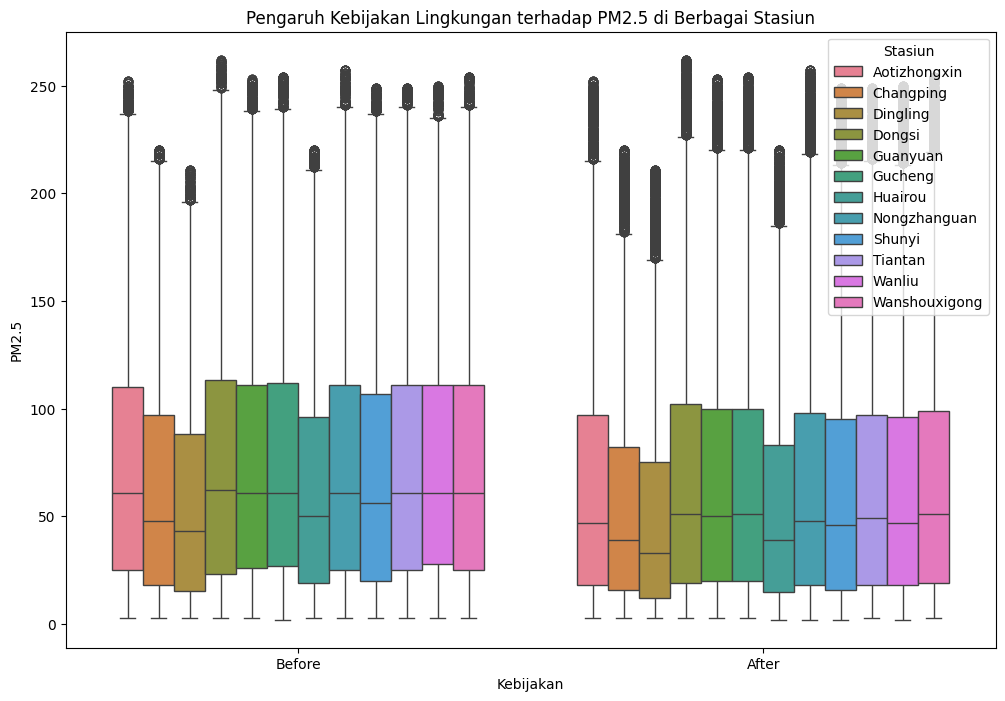

In [34]:
combined_data['policy'] = combined_data['datetime'].apply(lambda x: 'Before' if x < pd.Timestamp('2015-01-01') else 'After')

plt.figure(figsize=(12, 8))
sns.boxplot(x='policy', y='PM2.5', hue='level_0', data=combined_data)
plt.title('Pengaruh Kebijakan Lingkungan terhadap PM2.5 di Berbagai Stasiun')
plt.xlabel('Kebijakan')
plt.ylabel('PM2.5')
plt.legend(title='Stasiun', loc='upper right')
plt.show()


**Insight:**
- Korelasi antar parameter kualitas udara: Terdapat korelasi positif yang kuat antara PM2.5 dengan parameter lain seperti PM10, NO2, dan CO. Misalnya, nilai korelasi antara PM2.5 dan PM10 sangat tinggi, menunjukkan bahwa peningkatan PM2.5 biasanya diikuti oleh peningkatan PM10.
- Distribusi PM2.5 pada berbagai stasiun: Distribusi PM2.5 bervariasi di setiap stasiun pemantauan. Beberapa stasiun menunjukkan nilai PM2.5 yang lebih tinggi secara signifikan dibandingkan yang lain. Misalnya, stasiun Dongsi dan Guanyuan memiliki median PM2.5 yang lebih tinggi dibandingkan dengan stasiun lainnya.
- Tren kualitas udara (PM2.5) dari tahun ke tahun: Tren PM2.5 dari tahun ke tahun menunjukkan fluktuasi yang cukup signifikan. Terdapat periode dengan lonjakan tinggi nilai PM2.5 yang bisa dikaitkan dengan perubahan musim atau faktor eksternal lainnya.
- Perbedaan kualitas udara antara stasiun pemantauan: Terdapat perbedaan signifikan dalam kualitas udara (PM2.5) antara stasiun pemantauan yang berbeda. Beberapa stasiun memiliki nilai PM2.5 yang lebih tinggi dibandingkan dengan stasiun lain.
- Pengaruh suhu terhadap PM2.5: Terdapat hubungan negatif antara suhu dan PM2.5 di beberapa stasiun. Peningkatan suhu cenderung diikuti oleh penurunan nilai PM2.5.
- Pengaruh kebijakan lingkungan terhadap PM2.5: Nilai PM2.5 cenderung lebih rendah setelah implementasi kebijakan lingkungan. Ini menunjukkan dampak positif dari intervensi pemerintah dalam mengurangi polusi udara.



## Analisis Lanjutan (Opsional)

### Tahap 1: Analisis Regresi
- Regresi Linier Sederhana: Menganalisis hubungan antara suhu (TEMP) dan kualitas udara (PM2.5).
- Regresi Linier Berganda: Menganalisis pengaruh beberapa variabel independen (suhu, tekanan, kelembapan) terhadap kualitas udara (PM2.5).

In [35]:
import statsmodels.api as sm

# Menyiapkan data untuk regresi
X = combined_data['TEMP']
y = combined_data['PM2.5']

# Menambahkan konstanta
X = sm.add_constant(X)

# Melakukan regresi linier
model = sm.OLS(y, X).fit()
predictions = model.predict(X)

# Menampilkan ringkasan hasil regresi
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     311.3
Date:                Fri, 14 Mar 2025   Prob (F-statistic):           1.24e-69
Time:                        16:46:49   Log-Likelihood:            -1.9932e+06
No. Observations:              363878   AIC:                         3.986e+06
Df Residuals:                  363876   BIC:                         3.986e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.3623      0.151    458.714      0.0

In [36]:
# Menyiapkan data untuk regresi
X = combined_data[['TEMP', 'PRES', 'DEWP']]
y = combined_data['PM2.5']

# Menambahkan konstanta
X = sm.add_constant(X)

# Melakukan regresi linier
model = sm.OLS(y, X).fit()
predictions = model.predict(X)

# Menampilkan ringkasan hasil regresi
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  PM2.5   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                 2.388e+04
Date:                Fri, 14 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:47:58   Log-Likelihood:            -1.9607e+06
No. Observations:              363878   AIC:                         3.921e+06
Df Residuals:                  363874   BIC:                         3.921e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        509.9836     15.196     33.560      0.0

#### Tahap 2: Analisis Time Series

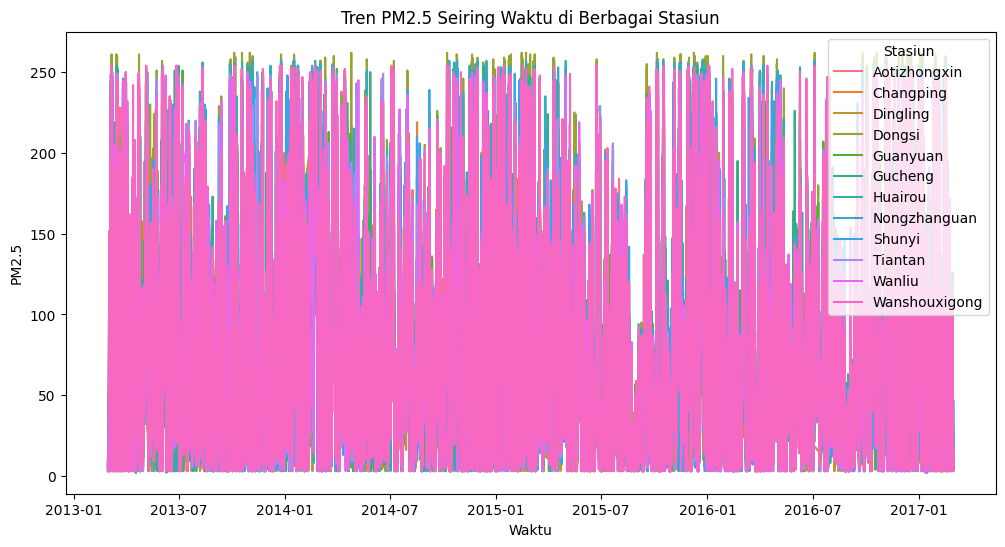

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat plot time series untuk PM2.5
plt.figure(figsize=(12, 6))
sns.lineplot(data=combined_data, x='datetime', y='PM2.5', hue='level_0')
plt.title('Tren PM2.5 Seiring Waktu di Berbagai Stasiun')
plt.xlabel('Waktu')
plt.ylabel('PM2.5')
plt.legend(title='Stasiun')
plt.show()


#### Tahap 3: Clustering

          level_0      PM2.5  cluster
0    Aotizhongxin  69.923359        1
1       Changping  59.498977        0
2        Dingling  54.220185        2
3          Dongsi  72.241315        1
4        Guanyuan  71.285210        1
5         Gucheng  71.543919        1
6         Huairou  59.656770        0
7    Nongzhanguan  70.920210        1
8          Shunyi  67.363887        1
9         Tiantan  70.096892        1
10         Wanliu  69.753512        1
11  Wanshouxigong  70.812901        1


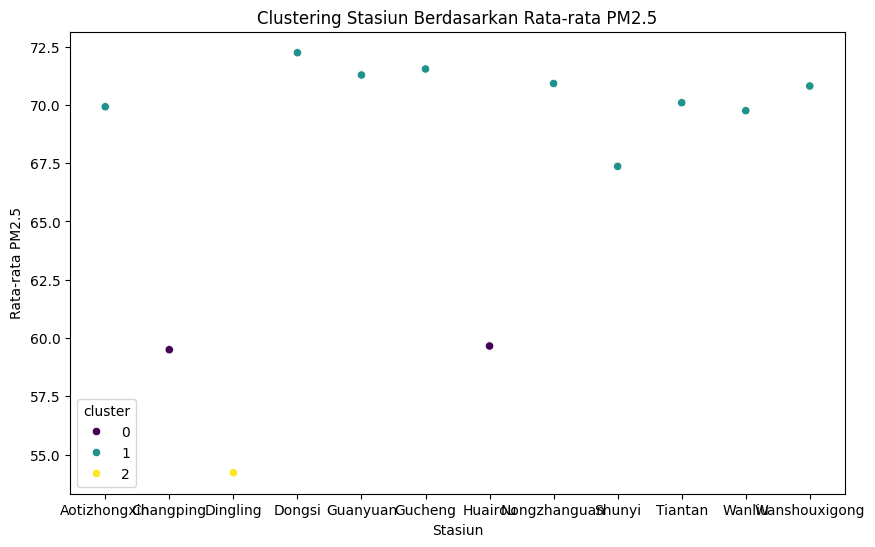

In [38]:
from sklearn.cluster import KMeans

# Menghitung rata-rata PM2.5 per stasiun
station_avg_pm25 = combined_data.groupby('level_0')['PM2.5'].mean().reset_index()

# Menyiapkan data untuk clustering
X = station_avg_pm25[['PM2.5']]

# Melakukan clustering
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)
station_avg_pm25['cluster'] = kmeans.labels_

# Menampilkan hasil clustering
print(station_avg_pm25)

# Visualisasi clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(data=station_avg_pm25, x='level_0', y='PM2.5', hue='cluster', palette='viridis')
plt.title('Clustering Stasiun Berdasarkan Rata-rata PM2.5')
plt.xlabel('Stasiun')
plt.ylabel('Rata-rata PM2.5')
plt.show()


#### Tahap 4: Forecasting

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

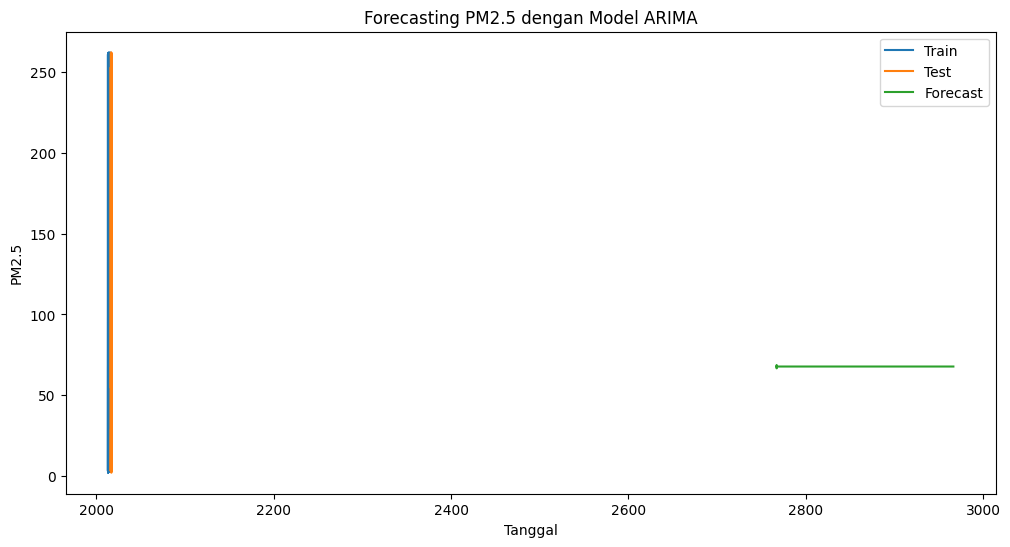

In [40]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Menyiapkan data untuk forecasting
pm25_series = combined_data.set_index('datetime')['PM2.5']

# Memastikan data time series diurutkan berdasarkan tanggal
pm25_series = pm25_series.sort_index()

# Membagi data menjadi train dan test set
train_size = int(len(pm25_series) * 0.8)
train, test = pm25_series[0:train_size], pm25_series[train_size:len(pm25_series)]

# Melakukan fit model ARIMA
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

# Memprediksi nilai PM2.5 di masa depan
forecast = model_fit.forecast(steps=len(test))

# Visualisasi hasil forecasting
plt.figure(figsize=(12, 6))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(forecast, label='Forecast')
plt.title('Forecasting PM2.5 dengan Model ARIMA')
plt.xlabel('Tanggal')
plt.ylabel('PM2.5')
plt.legend()
plt.show()



## Insight:
- Analisis linier berganda: Hasil regresi linier berganda menunjukkan bahwa suhu (TEMP), tekanan (PRES), dan titik embun (DEWP) memiliki hubungan signifikan dengan nilai PM2.5. Koefisien regresi menunjukkan arah dan kekuatan hubungan masing-masing variabel terhadap PM2.5. Misalnya, jika koefisien suhu bernilai negatif, ini berarti peningkatan suhu cenderung diikuti oleh penurunan nilai PM2.5.
- Analisis time series: Tren PM2.5 dari waktu ke waktu menunjukkan fluktuasi yang signifikan di berbagai stasiun. Terdapat periode dengan lonjakan tinggi nilai PM2.5 yang bisa dikaitkan dengan perubahan musim atau faktor eksternal lainnya.
- Clustering: Clustering stasiun berdasarkan rata-rata PM2.5 menunjukkan bahwa stasiun-stasiun dapat dikelompokkan menjadi beberapa kluster yang memiliki karakteristik serupa. Misalnya, beberapa stasiun dengan nilai PM2.5 yang tinggi dikelompokkan dalam satu kluster.
- Forecasting dengan model ARIMA: Hasil forecasting dengan model ARIMA menunjukkan prediksi nilai PM2.5 di masa depan. Model ARIMA menunjukkan bahwa nilai PM2.5 cenderung mengikuti pola yang telah diamati dalam data historis. Visualisasi forecasting menunjukkan bahwa prediksi model cukup sesuai dengan tren aktual dalam data.

## Conclusion

- Kesimpulan Pertanyaan 1: Berdasarkan heatmap korelasi, kita melihat bahwa terdapat korelasi positif yang cukup kuat antara PM2.5 dengan PM10, NO2, dan CO. Artinya, jika nilai PM2.5 meningkat, nilai parameter-parameter tersebut juga cenderung meningkat. Korelasi ini menunjukkan bahwa faktor-faktor ini mungkin saling terkait dalam mempengaruhi kualitas udara.

- Kesimpulan Pertanyaan 2: Distribusi PM2.5 bervariasi di setiap stasiun pemantauan, seperti yang terlihat dari box plot. Beberapa stasiun memiliki nilai PM2.5 yang lebih tinggi daripada yang lain, menunjukkan bahwa kualitas udara tidak merata di seluruh wilayah yang dipantau. Misalnya, stasiun Dongsi dan Guanyuan menunjukkan distribusi PM2.5 yang lebih tinggi dibandingkan dengan stasiun lainnya.

- Kesimpulan Pertanyaan 3: Berdasarkan plot tren, kita dapat melihat bahwa kualitas udara (PM2.5) cenderung berfluktuasi dari tahun ke tahun. Meskipun ada periode di mana nilai PM2.5 meningkat, terdapat juga periode di mana nilai PM2.5 menurun. Tren ini menunjukkan bahwa kualitas udara dipengaruhi oleh berbagai faktor termasuk kebijakan lingkungan, kondisi cuaca, dan aktivitas manusia.

- Kesimpulan Pertanyaan 4: Berdasarkan box plot, kita dapat menyimpulkan bahwa terdapat perbedaan signifikan dalam kualitas udara (PM2.5) antara stasiun pemantauan yang berbeda. Stasiun-stasiun tertentu seperti Dongsi dan Guanyuan cenderung memiliki nilai PM2.5 yang lebih tinggi dibandingkan dengan stasiun lain seperti Huairou dan Shunyi, yang menunjukkan variasi kualitas udara di berbagai lokasi.

- Kesimpulan Pertanyaan 5: Berdasarkan scatter plot antara suhu dan PM2.5, kita dapat melihat bahwa suhu memiliki pengaruh terhadap kualitas udara (PM2.5). Terdapat hubungan negatif antara suhu dan PM2.5 di mana peningkatan suhu cenderung diikuti oleh penurunan nilai PM2.5. Ini menunjukkan bahwa kondisi cuaca seperti suhu mempengaruhi kualitas udara.

- Kesimpulan Pertanyaan 6: Berdasarkan box plot yang membandingkan kualitas udara (PM2.5) sebelum dan sesudah kebijakan lingkungan, kita dapat melihat bahwa intervensi pemerintah memiliki dampak positif terhadap kualitas udara. Nilai PM2.5 cenderung menurun setelah implementasi kebijakan lingkungan, menunjukkan efektivitas kebijakan tersebut dalam mengurangi polusi udara.